In [28]:
#!pkill node

In [29]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix

# ==========================================
# CONFIGURACIÓN DEL PROYECTO
# ==========================================
PATH_BASE = "/content/dataset-cazas"        # Carpeta de entrenamiento
PATH_TEST = "/content/dataset-test"         # Carpeta de pruebas externas
MODELO_BINARIO = "/content/cazas_final.keras" # Archivo físico del modelo
CLASES_FILE = "/content/clases_nombres.npy"   # Archivo para nombres de aviones

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 0.001
# ==========================================

In [5]:
if not os.path.exists(PATH_BASE) and not os.path.exists(PATH_TEST):
  if not os.path.exists('/conent/drive'):
    from google.colab import drive
    import shutil
    drive.mount('/content/drive')
    print('Drive montado')

  #Busca si existe el datase.zip en todo google drive del usuario
  ruta_dataset = !find -name dataset.zip
  if ruta_dataset:
    origen = ruta_dataset
    destino = '/tmp'
    archivo = '/tmp/dataset.zip'

    !cp {origen[0]} {destino}
    print('Archivo el tmp listo para descomprimir')
    !unzip {archivo} > /dev/null 2>&1 && echo "Termino descompresion"
  else:
    raise Exception("Dataset no encontrado en drive")
else:
  print("Dastos listo")

archivos encontrados


# Verificación de Imágenes

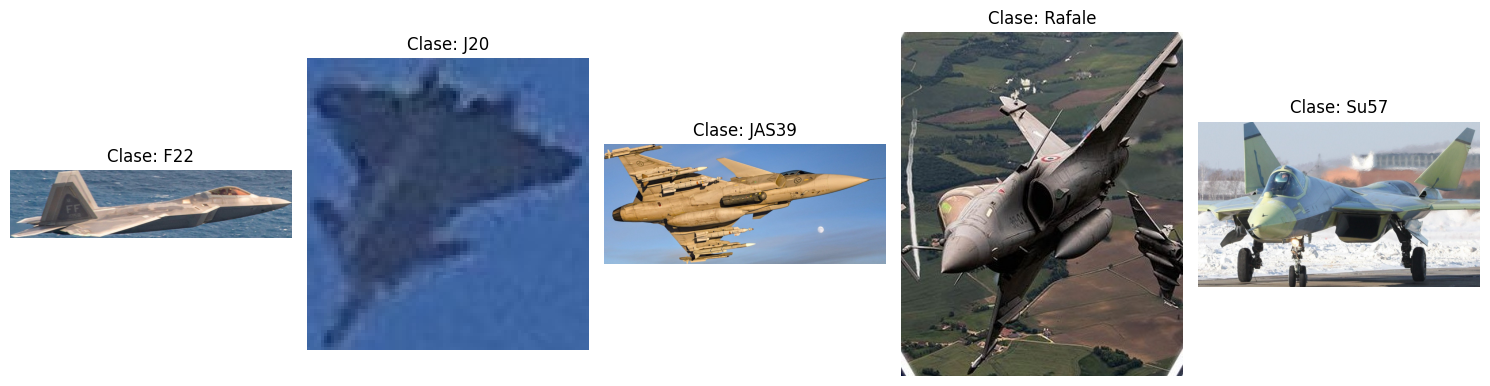

In [31]:
folders = sorted([f for f in os.listdir(PATH_BASE) if os.path.isdir(os.path.join(PATH_BASE, f))])
fig, axes = plt.subplots(1, len(folders), figsize=(15, 5))

for i, name in enumerate(folders):
    folder_path = os.path.join(PATH_BASE, name)
    files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if files:
        img = mpimg.imread(os.path.join(folder_path, files[0]))
        axes[i].imshow(img)
        axes[i].set_title(f"Clase: {name}")
        axes[i].axis('off')

plt.tight_layout()
plt.show()

# Carga de Datos y Optimización

In [32]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    PATH_BASE, validation_split=0.2, subset="training", seed=123,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE)

val_ds = tf.keras.utils.image_dataset_from_directory(
    PATH_BASE, validation_split=0.2, subset="validation", seed=123,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE)

class_names = train_ds.class_names
np.save(CLASES_FILE, class_names)

# Optimización de Memoria
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 2128 files belonging to 5 classes.
Using 1703 files for training.
Found 2128 files belonging to 5 classes.
Using 425 files for validation.


# Arquitectura EfficientNetB0 (Transfer Learning)

In [33]:
run_a = True
if run_a:
  base_model = tf.keras.applications.EfficientNetB0(
      input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
      include_top=False,
      weights='imagenet'
  )
  base_model.trainable = False

  model = models.Sequential([
      layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
      base_model,
      layers.GlobalAveragePooling2D(),
      layers.BatchNormalization(),
      layers.Dropout(0.4),
      layers.Dense(len(class_names), activation='softmax')
  ])

  model.compile(
      optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
      loss='sparse_categorical_crossentropy',
      metrics=['accuracy']
  )

  checkpoint = tf.keras.callbacks.ModelCheckpoint(MODELO_BINARIO, save_best_only=True, monitor='val_accuracy')

  history = model.fit(
      train_ds,
      validation_data=val_ds,
      epochs=EPOCHS,
      callbacks=[checkpoint]
  )

Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 50s 483ms/step - accuracy: 0.3230 - loss: 1.9385 - val_accuracy: 0.4988 - val_loss: 1.3526
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.4997 - loss: 1.3853 - val_accuracy: 0.6000 - val_loss: 1.1864
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.6119 - loss: 1.0875 - val_accuracy: 0.6282 - val_loss: 1.0603
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.6453 - loss: 0.9698 - val_accuracy: 0.6494 - val_loss: 0.9875
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.6876 - loss: 0.8801 - val_accuracy: 0.6894 - val_loss: 0.9092
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.7105 - loss: 0.8201 - val_accuracy: 0.6800 - val_loss: 0.8732
Epoch 7/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.7076 - loss: 0.7901 - val_accuracy: 0.6918 - val_loss: 0.8557
Epoch 8/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.7363 - loss: 0.7424 - val_accuracy: 0.6965 -

# Comportamiento del entrenamiento normal

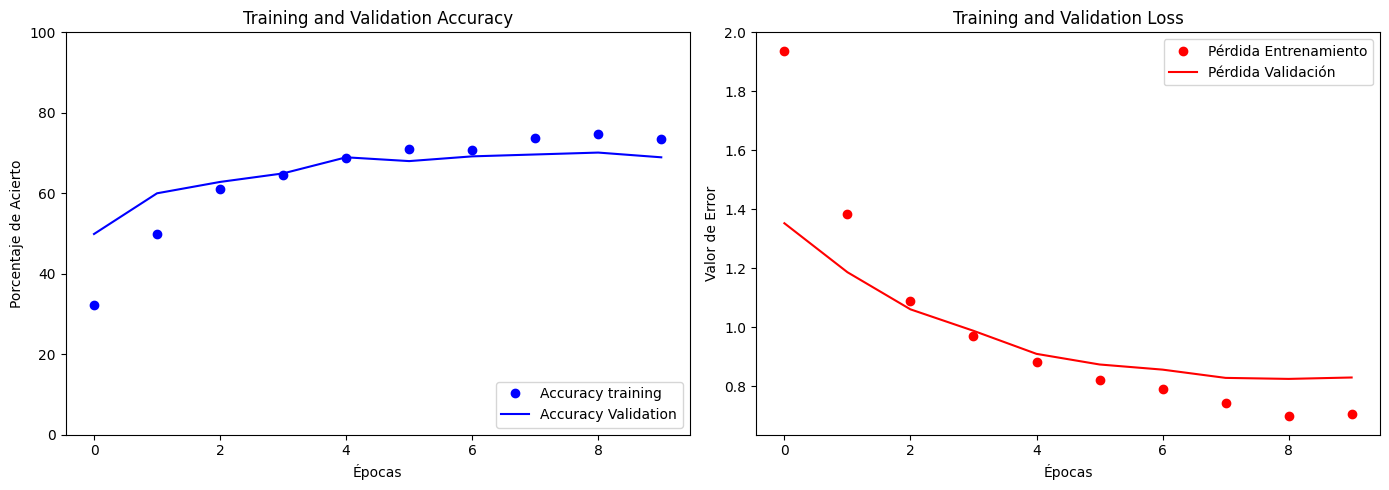

In [34]:
# =============================================================
# CELDA 13: Graficar historial de entrenamiento normal
# =============================================================

# Extraer historial del objeto 'history' (el que usamos en el fit de cazas)
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

# Crear la figura con dos sub-gráficas
plt.figure(figsize=(14, 5))

# --- Gráfica 1: Precisión (Accuracy) ---
plt.subplot(1, 2, 1)
# Puntos azules para entrenamiento, línea azul para validación
plt.plot(epochs_range, [x * 100 for x in acc], 'bo', label='Accuracy training')
plt.plot(epochs_range, [x * 100 for x in val_acc], 'b', label='Accuracy Validation')
plt.title('Training and Validation Accuracy')
plt.xlabel('Épocas')
plt.ylabel('Porcentaje de Acierto')
plt.ylim(0, 100) # Forzamos de 0 a 100 para que se vea real
plt.legend(loc='lower right')

# --- Gráfica 2: Pérdida (Loss) ---
plt.subplot(1, 2, 2)
# Puntos rojos para entrenamiento, línea roja para validación
plt.plot(epochs_range, loss, 'ro', label='Pérdida Entrenamiento')
plt.plot(epochs_range, val_loss, 'r', label='Pérdida Validación')
plt.title('Training and Validation Loss')
plt.xlabel('Épocas')
plt.ylabel('Valor de Error')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Fine tuning

In [35]:
run_t = True
if run_t:
  # 1. CARGAMOS el modelo que ya tiene conocimiento
  print("Cargando modelo previo...")
  model = tf.keras.models.load_model(MODELO_BINARIO)

  # 2. Desbloqueamos las capas para el ajuste fino
  model.trainable = True

  # 3. Re-compilamos con la velocidad de aprendizaje lenta
  model.compile(
      optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
      loss='sparse_categorical_crossentropy',
      metrics=['accuracy']
  )

  # 4. Continuamos el entrenamiento
  history_fine = model.fit(
      train_ds,
      validation_data=val_ds,
      epochs=10,
      callbacks=[checkpoint]
)

Cargando modelo previo...
Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 46s 436ms/step - accuracy: 0.7786 - loss: 0.6334 - val_accuracy: 0.6847 - val_loss: 0.8199
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.7998 - loss: 0.6122 - val_accuracy: 0.6894 - val_loss: 0.8189
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.7575 - loss: 0.6592 - val_accuracy: 0.6965 - val_loss: 0.8160
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.7863 - loss: 0.5855 - val_accuracy: 0.6965 - val_loss: 0.8172
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.7863 - loss: 0.6163 - val_accuracy: 0.6988 - val_loss: 0.8129
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.7798 - loss: 0.6000 - val_accuracy: 0.6965 - val_loss: 0.8093
Epoch 7/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.7839 - loss: 0.6096 - val_accuracy: 0.6965 - val_loss: 0.8073
Epoch 8/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.7751 - loss: 0.623

# Comportamiento del entrenamiento tuning

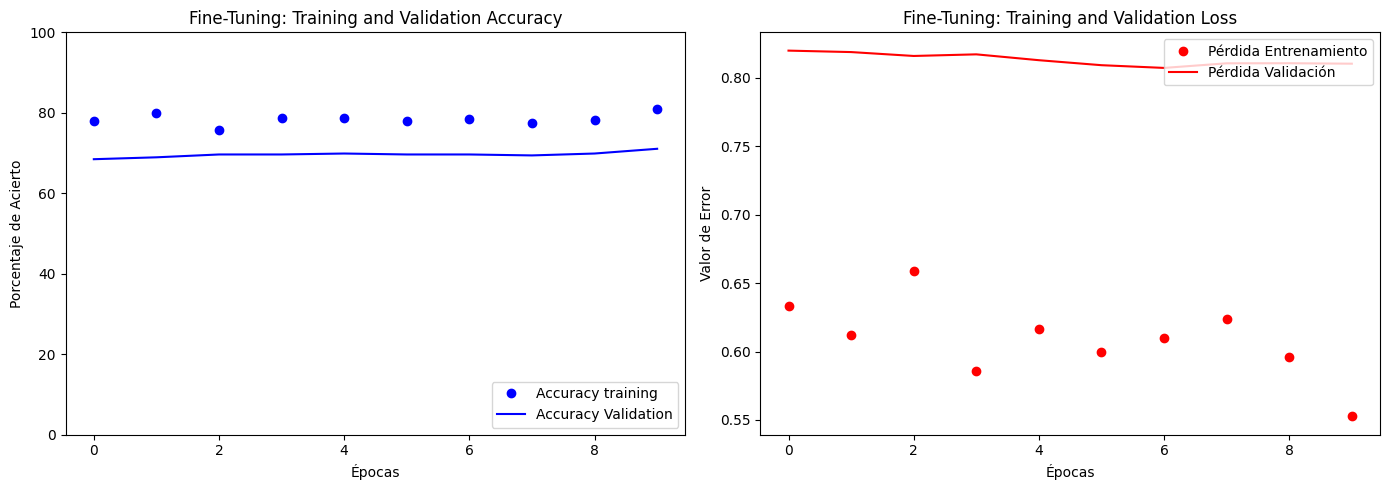

In [36]:
# =============================================================
# CELDA 13.1: Graficar historial de FINE-TUNING
# =============================================================

# Extraer historial del objeto 'history_fine'
acc_f = history_fine.history['accuracy']
val_acc_f = history_fine.history['val_accuracy']
loss_f = history_fine.history['loss']
val_loss_f = history_fine.history['val_loss']
epochs_range_f = range(len(acc_f))

# Crear la figura con dos sub-gráficas
plt.figure(figsize=(14, 5))

# --- Gráfica 1: Precisión (Accuracy) ---
plt.subplot(1, 2, 1)
# Puntos azules para entrenamiento, línea azul para validación (COMO LA ANTERIOR)
plt.plot(epochs_range_f, [x * 100 for x in acc_f], 'bo', label='Accuracy training')
plt.plot(epochs_range_f, [x * 100 for x in val_acc_f], 'b', label='Accuracy Validation')
plt.title('Fine-Tuning: Training and Validation Accuracy')
plt.xlabel('Épocas')
plt.ylabel('Porcentaje de Acierto')
plt.ylim(0, 100) # Mantener misma escala de 0 a 100
plt.legend(loc='lower right')

# --- Gráfica 2: Pérdida (Loss) ---
plt.subplot(1, 2, 2)
# Puntos rojos para entrenamiento, línea roja para validación (COMO LA ANTERIOR)
plt.plot(epochs_range_f, loss_f, 'ro', label='Pérdida Entrenamiento')
plt.plot(epochs_range_f, val_loss_f, 'r', label='Pérdida Validación')
plt.title('Fine-Tuning: Training and Validation Loss')
plt.xlabel('Épocas')
plt.ylabel('Valor de Error')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

# CARGA Y REPORTE

In [37]:
# Cargamos el binario del disco
model_ready = tf.keras.models.load_model(MODELO_BINARIO)
labels = np.load(CLASES_FILE)

y_true, y_pred = [], []
for x, y in val_ds:
    y_true.extend(y.numpy())
    y_pred.extend(np.argmax(model_ready.predict(x, verbose=0), axis=-1))

print("\n" + "="*60)
print("             REPORTE DE CLASIFICACIÓN DETALLADO")
print("="*60)
# Esto muestra Accuracy, Recall, F1-Score y Support por cada avión
print(classification_report(y_true, y_pred, target_names=labels))


             REPORTE DE CLASIFICACIÓN DETALLADO
              precision    recall  f1-score   support

         F22       0.69      0.68      0.69        82
         J20       0.77      0.75      0.76       105
       JAS39       0.68      0.66      0.67        79
      Rafale       0.66      0.70      0.68        87
        Su57       0.74      0.75      0.74        72

    accuracy                           0.71       425
   macro avg       0.71      0.71      0.71       425
weighted avg       0.71      0.71      0.71       425



# MATRIZ DE CONFUSIÓN

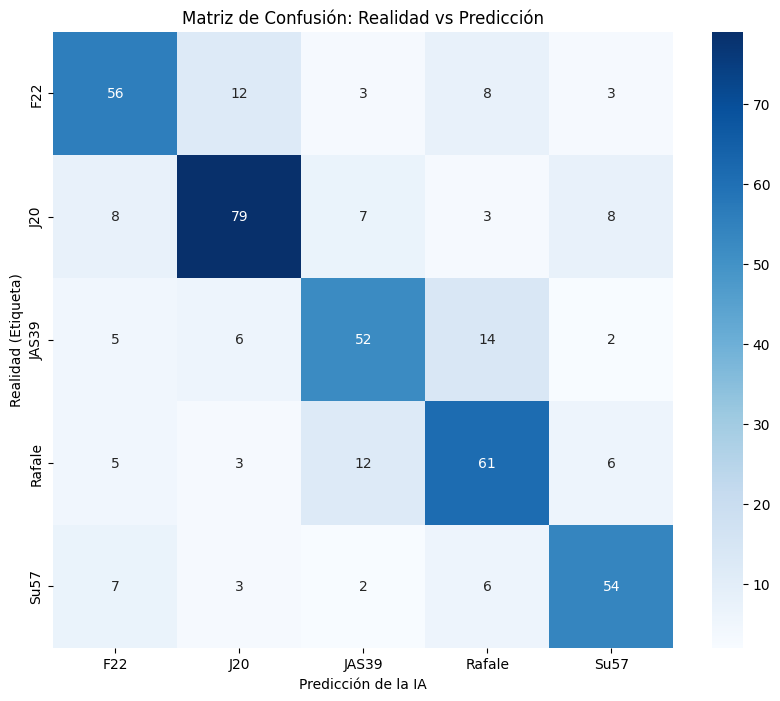

In [38]:
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title('Matriz de Confusión: Realidad vs Predicción')
plt.xlabel('Predicción de la IA')
plt.ylabel('Realidad (Etiqueta)')
plt.show()

# VISUALIZADOR DE ACIERTOS Y ERRORES

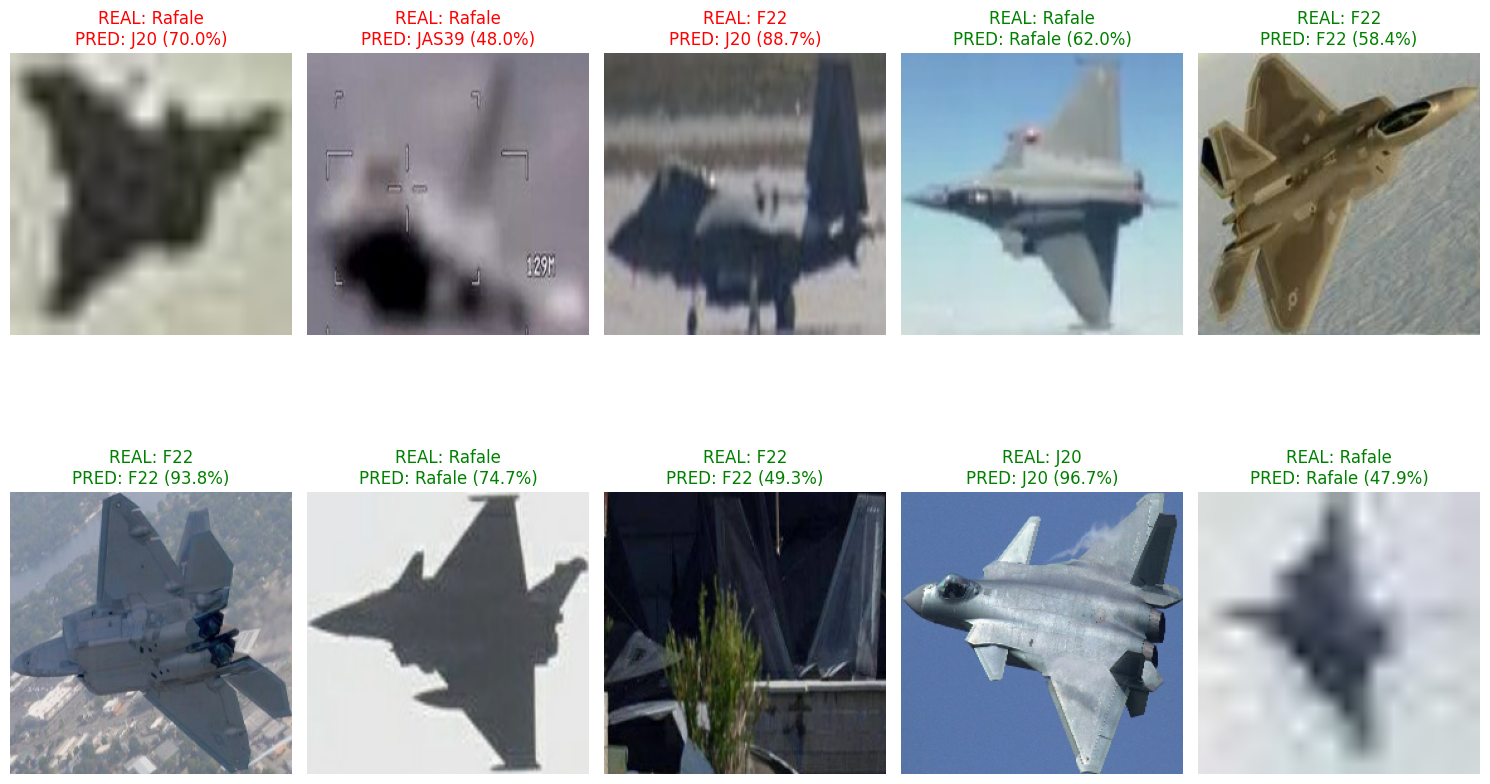

In [39]:
plt.figure(figsize=(15, 10))
# Tomamos fotos del set de validación
for images, labels_batch in val_ds.take(1):
    preds = model_ready.predict(images, verbose=0)

    for i in range(10): # Mostramos las primeras 10 fotos
        actual = labels[labels_batch[i]]
        pred_idx = np.argmax(preds[i])
        predicho = labels[pred_idx]
        confianza = 100 * np.max(preds[i])

        color = 'green' if actual == predicho else 'red'

        plt.subplot(2, 5, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(f"REAL: {actual}\nPRED: {predicho} ({confianza:.1f}%)", color=color)
        plt.axis("off")
plt.tight_layout()
plt.show()

# Prueba con Carpeta Test

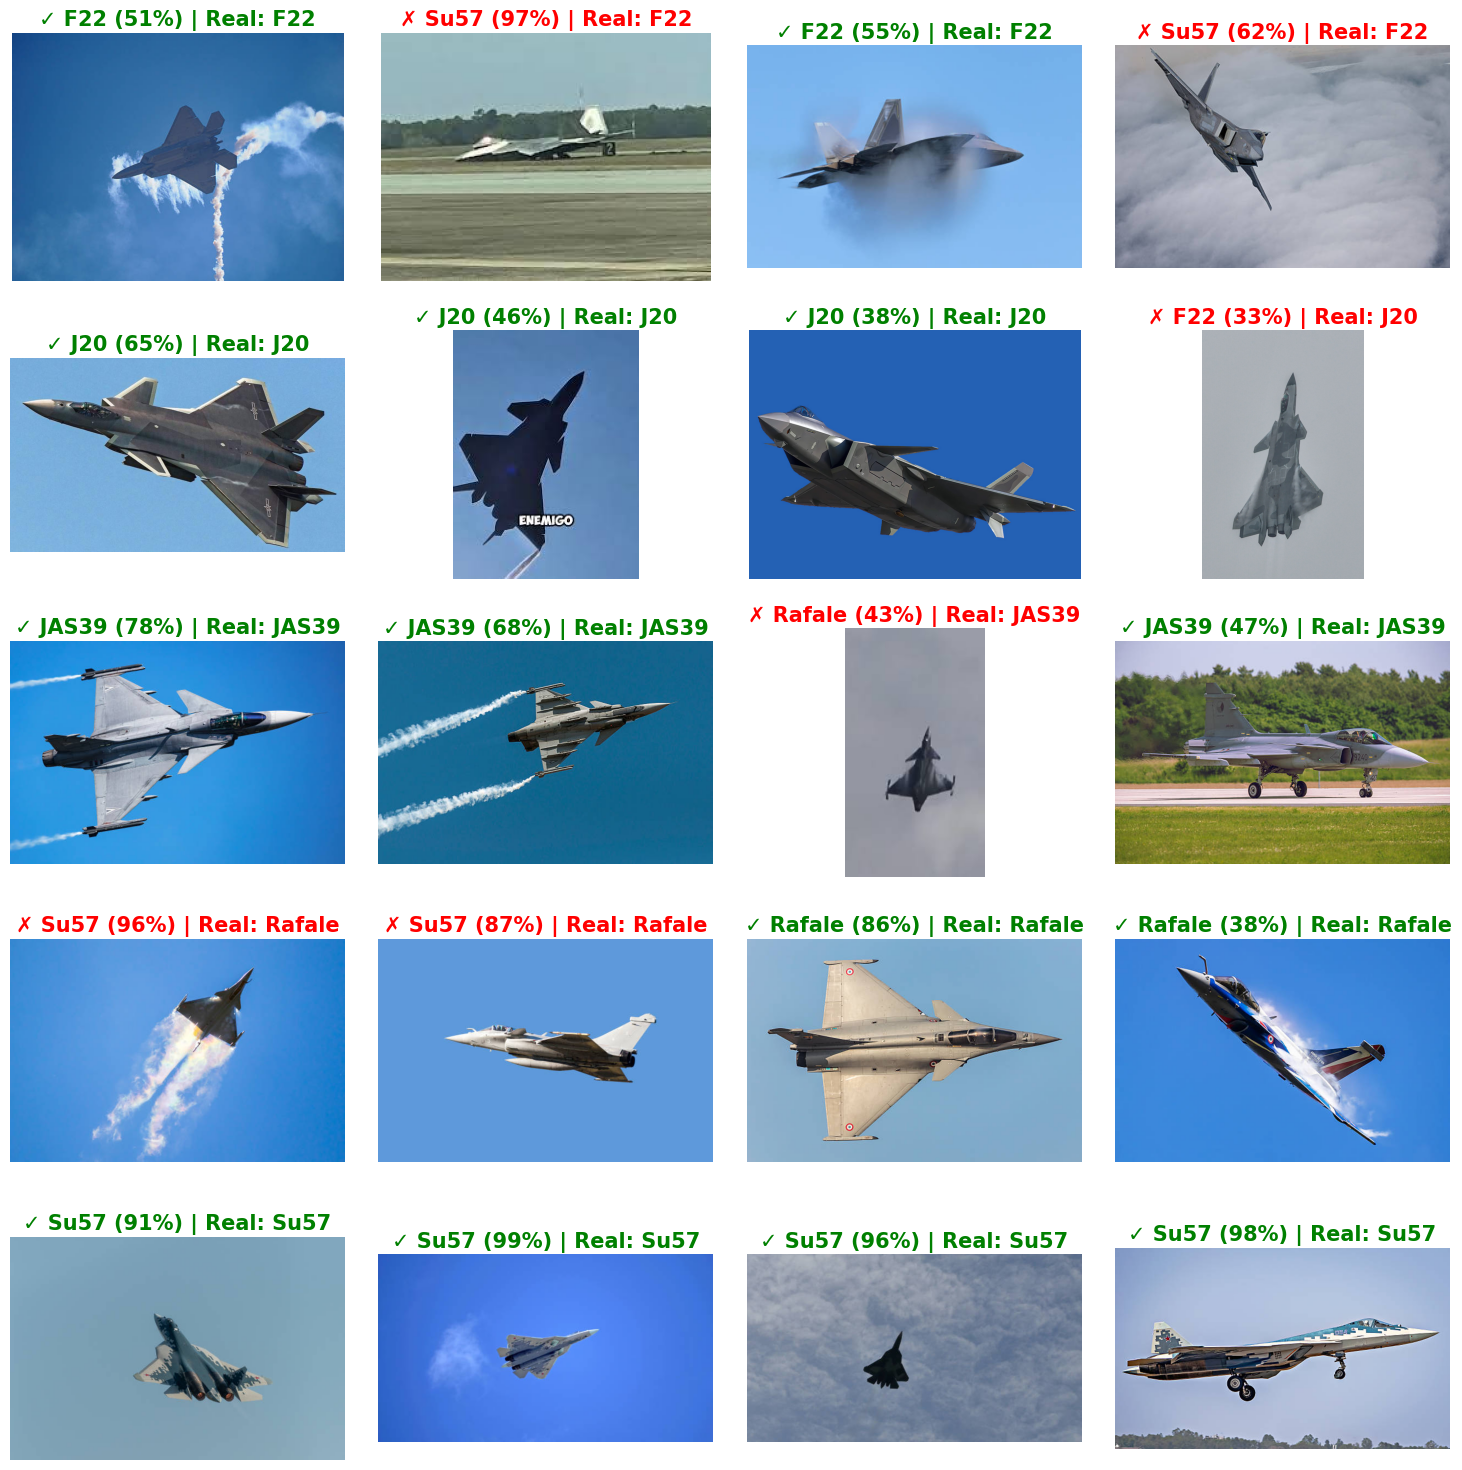

In [40]:
def prueba_maestra_test(folder, num_fotos=20):
    import os

    exts = ('.jpg', '.jpeg', '.png', '.webp')
    archivos = sorted([f for f in os.listdir(folder) if f.lower().endswith(exts)])

    if not archivos:
        return print(f"No se encontraron fotos en {folder}")

    cols = 4
    n_fotos = min(len(archivos), num_fotos)
    rows = (n_fotos + cols - 1) // cols

    # AJUSTE 1: Reducimos el alto de 4 a 3.2 para "apretar" las filas verticalmente
    plt.figure(figsize=(16, rows * 3.2))

    for i, filename in enumerate(archivos[:n_fotos]):
        path = os.path.join(folder, filename)

        # --- Predicción ---
        img_prep = tf.keras.utils.load_img(path, target_size=IMG_SIZE)
        img_array = tf.keras.utils.img_to_array(img_prep)
        img_batch = np.expand_dims(img_array, axis=0)

        preds = model_ready.predict(img_batch, verbose=0)
        pred_idx = np.argmax(preds[0])
        clase_predicha = labels[pred_idx]
        confianza = 100 * preds[0][pred_idx]

        # --- Lógica de Verificación ---
        es_correcto = False
        nombre_real = "Desconocido"
        fname_norm = filename.lower().replace("-", "").replace("_", "")

        for nombre_clase in labels:
            clase_norm = nombre_clase.lower().replace("-", "").replace("_", "")
            if clase_norm in fname_norm:
                nombre_real = nombre_clase
                if nombre_clase == clase_predicha:
                    es_correcto = True
                break

        # --- Visualización ---
        color = 'green' if es_correcto else 'red'
        if nombre_real == "Desconocido": color = 'orange'

        plt.subplot(rows, cols, i + 1)

        img_full = tf.keras.utils.load_img(path)
        plt.imshow(img_full)

        resultado_txt = "✓" if es_correcto else "✗"
        if nombre_real == "Desconocido": resultado_txt = "?"

        titulo = f"{resultado_txt} {clase_predicha} ({confianza:.0f}%) | Real: {nombre_real}"
        plt.title(titulo, color=color, fontsize=15, fontweight='bold', pad=5)
        plt.axis('off')

    plt.subplots_adjust(hspace=0.2, wspace=0.1, top=0.95, bottom=0.05, left=0.05, right=0.95)
    plt.show()

# Ejecución
prueba_maestra_test(PATH_TEST, num_fotos=20)